In [1]:
import pandas as pd

In [16]:
df=pd.read_csv('data/lodhi_hourly_with_weather.csv')

In [17]:
df.head()

,_id,Station ID,State,City,Station Name,Timestamp,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),...,MP-Xylene (ug/m3),AT (degC),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,1,site_109,Delhi,Delhi,"Lodhi Road, Delhi - IMD",2024-01-01T00:00:00,124.03,193.80,8.58,11.47,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,2,site_109,Delhi,Delhi,"Lodhi Road, Delhi - IMD",2024-01-01T00:15:00,124.91,187.90,8.80,10.67,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,3,site_109,Delhi,Delhi,"Lodhi Road, Delhi - IMD",2024-01-01T00:30:00,120.48,187.43,8.78,11.07,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,4,site_109,Delhi,Delhi,"Lodhi Road, Delhi - IMD",2024-01-01T00:45:00,122.33,192.50,8.76,11.11,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,5,site_109,Delhi,Delhi,"Lodhi Road, Delhi - IMD",2024-01-01T01:00:00,140.83,207.46,8.43,11.32,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [18]:

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp").sort_index()
print(df.index.min(), df.index.max())

2024-01-01 00:00:00 2025-12-31 23:45:00


In [19]:
# saare columns ke naam
print(df.columns.tolist())

# kis column mein kitna % missing hai
print((df.isna().mean() * 100).round(1).sort_values(ascending=False))

['_id', 'Station ID', 'State', 'City', 'Station Name', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Xylene (ug/m3)', 'O Xylene (ug/m3)', 'Eth-Benzene (ug/m3)', 'MP-Xylene (ug/m3)', 'AT (degC)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'RF (mm)', 'TOT-RF (mm)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)']
VWS (m/s)              100.0
BP (mmHg)              100.0
SR (W/mt2)             100.0
RF (mm)                100.0
WD (deg)               100.0
WS (m/s)               100.0
RH (%)                 100.0
AT (degC)              100.0
MP-Xylene (ug/m3)      100.0
NH3 (ug/m3)            100.0
SO2 (ug/m3)            100.0
Eth-Benzene (ug/m3)    100.0
O Xylene (ug/m3)       100.0
Toluene (ug/m3)         37.8
Xylene (ug/m3)          37.8
Benzene (ug/m3)         37.8
NO2 (ug/m3)             16.3
PM10 (ug/m3)            10.9
PM2.5 (ug/m3)           10.8
NO (ug/m3)              1

In [20]:
df.shape

(70177, 29)

In [21]:
# sirf kaam ke columns rakhe, baaki khaali ya bahut missing the
cols = ["PM2.5 (ug/m3)", "PM10 (ug/m3)", "NO (ug/m3)", "NO2 (ug/m3)",
        "NOx (ppb)", "CO (mg/m3)", "Ozone (ug/m3)"]
data = df[cols].copy()

# duplicate timestamps kitne hain
print(data.index.duplicated().sum())
data = data[~data.index.duplicated(keep="first")]

0


In [22]:
# 15 min se hourly average
hourly = data.resample("1h").mean()
print(hourly.shape)
print((hourly.isna().mean() * 100).round(1))

(17544, 7)
PM2.5 (ug/m3)    10.0
PM10 (ug/m3)     10.4
NO (ug/m3)       10.1
NO2 (ug/m3)      15.7
NOx (ppb)         9.7
CO (mg/m3)        9.6
Ozone (ug/m3)    10.0
dtype: float64


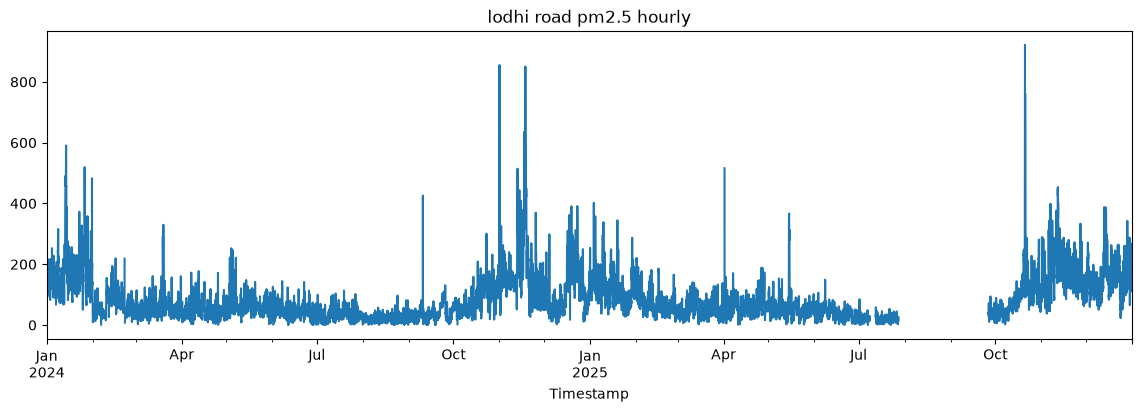

In [23]:
import matplotlib.pyplot as plt

hourly["PM2.5 (ug/m3)"].plot(figsize=(14, 4))
plt.title("lodhi road pm2.5 hourly")
plt.show()

In [24]:
# kahan kahan lamba gap hai dekhte hain
pm = hourly["PM2.5 (ug/m3)"]
is_na = pm.isna()

# har continuous missing block ko ek number de diya
blocks = (is_na != is_na.shift()).cumsum()
gap_len = is_na.groupby(blocks).sum()

# 6 ghante se lambe gaps hi print karenge
for b in gap_len[gap_len > 6].index:
    idx = pm[blocks == b].index
    print(idx.min(), "to", idx.max(), "->", len(idx), "hours")
    

2024-01-30 16:00:00 to 2024-01-31 10:00:00 -> 19 hours
2024-03-02 18:00:00 to 2024-03-03 10:00:00 -> 17 hours
2025-04-01 00:00:00 to 2025-04-01 14:00:00 -> 15 hours
2025-04-29 15:00:00 to 2025-04-30 12:00:00 -> 22 hours
2025-06-20 16:00:00 to 2025-06-21 08:00:00 -> 17 hours
2025-07-08 16:00:00 to 2025-07-12 10:00:00 -> 91 hours
2025-07-27 20:00:00 to 2025-09-26 09:00:00 -> 1454 hours
2025-11-25 20:00:00 to 2025-11-26 13:00:00 -> 18 hours


In [25]:
# chhote gaps (6 ghante tak) interpolate, lamba gap waise hi chhod diya
hourly_f = hourly.interpolate(limit=6, limit_area="inside")
print((hourly_f.isna().mean() * 100).round(1))

PM2.5 (ug/m3)     9.1
PM10 (ug/m3)      9.5
NO (ug/m3)        9.1
NO2 (ug/m3)      14.7
NOx (ppb)         9.1
CO (mg/m3)        9.3
Ozone (ug/m3)     9.3
dtype: float64


In [26]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 28.59, "longitude": 77.23,   # lodhi road ke aas paas
    "start_date": "2024-01-01", "end_date": "2025-12-31",
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,surface_pressure,precipitation",
    "timezone": "Asia/Kolkata",
}
r = requests.get(url, params=params)
r.raise_for_status()

weather = pd.DataFrame(r.json()["hourly"])
weather["time"] = pd.to_datetime(weather["time"])
weather = weather.set_index("time")
print(weather.shape)

(17544, 6)


In [28]:
# pollution + weather ek table mein, time ke hisaab se
final = hourly_f.join(weather, how="left")
print(final.shape)
print(final.isna().mean().mul(100).round(1))

final.to_csv("data/lodhi_hourly_with_weather.csv")

(17544, 13)
PM2.5 (ug/m3)            9.1
PM10 (ug/m3)             9.5
NO (ug/m3)               9.1
NO2 (ug/m3)             14.7
NOx (ppb)                9.1
CO (mg/m3)               9.3
Ozone (ug/m3)            9.3
temperature_2m           0.0
relative_humidity_2m     0.0
wind_speed_10m           0.0
wind_direction_10m       0.0
surface_pressure         0.0
precipitation            0.0
dtype: float64


In [29]:
import os

print(os.getcwd())
print(os.listdir())

/Users/najeebahmad/Desktop/AQI-PRED-RAG
['notebook.ipynb', 'venv', '.vscode', 'data', 'notebooks']


In [30]:
import os

for root, dirs, files in os.walk(".."):
    if "lodhi_hourly_with_weather.csv" in files:
        print(os.path.join(root, "lodhi_hourly_with_weather.csv"))

../AQI-PRED-RAG/data/lodhi_hourly_with_weather.csv


In [1]:
from pathlib import Path

ROOT = Path.cwd().parent
print("Project root:", ROOT)

for f in ROOT.rglob("*.csv"):
    print(f)

Project root: /Users/najeebahmad/Desktop/AQI-PRED-RAG
/Users/najeebahmad/Desktop/AQI-PRED-RAG/data/raw/lodhi_hourly_with_weather.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/data/raw/aqi_hourly_with_weather.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/data/raw/lodhi-2017-2023.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/data/raw/aqi_hourly_v2.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/venv/lib/python3.13/site-packages/scipy/signal/tests/data/GLB.Ts+dSST.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/venv/lib/python3.13/site-packages/matplotlib/mpl-data/sample_data/msft.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/venv/lib/python3.13/site-packages/matplotlib/mpl-data/sample_data/data_x_x2_x3.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/venv/lib/python3.13/site-packages/matplotlib/mpl-data/sample_data/Stocks.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/venv/lib/python3.13/site-packages/sklearn/datasets/data/wine_data.csv
/Users/najeebahmad/Desktop/AQI-PRED-RAG/venv/lib/python3.13/site-packages/s